# 🌿 03 · EDA narrado: la historia de los datos

Este es el notebook **estrella**. Aquí ya no preparamos datos: los **interrogamos** para contar una historia,
apoyándonos en gráficos y en teoría estadística explicada al momento.

La historia sigue dos hilos:
- 🧪 **Químico-medicinal** — potencia (THC/CBD), efectos y usos terapéuticos.
- 💰 **Mercado** — qué determina el precio de una cepa.

Cada sección arranca con una **pregunta**, la responde con datos y cierra con una **interpretación**.

> 🧠 **Cómo leer este notebook:** las cajas con 🧠 explican el concepto estadístico que se usa justo después.
> Si ya lo dominas, puedes saltarlas; si no, te dan justo lo necesario para entender el gráfico.

---
## Preparación

Gracias a la limpieza del notebook `02`, cargar los datos listos es **una sola línea**: `clean(load_raw())`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_raw, clean, explode_multi
from src.viz import set_style, save_fig, PALETTE, TYPE_COLORS

set_style()   # aplica el estilo visual del proyecto a todos los gráficos

df = clean(load_raw())
print("Datos listos:", df.shape)

Datos listos: (8910, 47)


# Parte 1 · Perfil químico 🧪

Empezamos por lo que más conecta con la biomedicina: **la composición química**. El THC es el compuesto
psicoactivo (el "efecto"); el CBD es el no psicoactivo, asociado a usos terapéuticos (dolor, ansiedad,
inflamación). Cuatro preguntas guían esta parte:

1. ¿Cómo de potentes son las cepas? (distribución del THC)
2. ¿Cuánto CBD tienen? (distribución del CBD)
3. ¿Cambia la potencia según el tipo (Indica/Sativa/Híbrido)?
4. ¿THC y CBD van de la mano?

## 1. ¿Cómo de potentes son las cepas?

> 🧠 **Distribución.** Una *distribución* muestra cómo se reparten los valores: qué valores son comunes y
> cuáles raros. El **histograma** es la forma clásica de verla: parte el rango en "cajones" (bins) y cuenta
> cuántas cepas caen en cada uno. La altura de cada barra = cuántas cepas tienen ese nivel de THC.
>
> Marcamos dos medidas de "centro":
> - **Media** (promedio): suma todo y divide. Sensible a valores extremos.
> - **Mediana**: el valor del medio si ordenas todos los datos. Robusta frente a extremos.
>
> Si la **media y la mediana casi coinciden**, la distribución es simétrica. Si la media es mayor que la
> mediana, hay una "cola" hacia la derecha (**sesgo positivo**): unos pocos valores altos la estiran.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\01_distribucion_thc.png


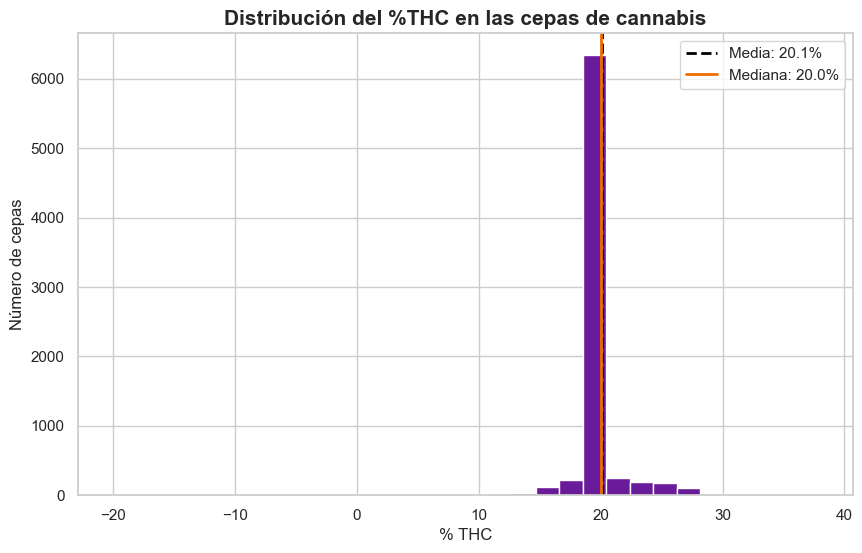

In [2]:
media_thc = df["thc_pct"].mean()
mediana_thc = df["thc_pct"].median()

fig, ax = plt.subplots()
ax.hist(df["thc_pct"], bins=30, color=PALETTE["purple"], edgecolor="white")
# Líneas verticales para media y mediana
ax.axvline(media_thc, color="black", linestyle="--", linewidth=2, label=f"Media: {media_thc:.1f}%")
ax.axvline(mediana_thc, color=PALETTE["orange"], linestyle="-", linewidth=2, label=f"Mediana: {mediana_thc:.1f}%")

ax.set_title("Distribución del %THC en las cepas de cannabis")
ax.set_xlabel("% THC")
ax.set_ylabel("Número de cepas")
ax.legend()
save_fig("01_distribucion_thc")
plt.show()

**¡Alto! Algo huele raro.** El histograma no parece una distribución natural: es **una sola barra gigante**
en 20%. Eso no pasa en datos reales de miles de cepas distintas. Cuando un gráfico se ve "demasiado
perfecto", hay que **desconfiar e investigar**. Contemos los valores exactos de THC:

In [3]:
# ¿Qué valores de THC son los más frecuentes?
print(df["thc_pct"].value_counts().head(5))

pct_en_20 = (df["thc_pct"] == 20.0).mean() * 100
print(f"\n% de cepas con THC == 20.0 exacto: {pct_en_20:.0f}%")
print(f"Valor mínimo de THC: {df['thc_pct'].min()}   <- ¡ojo, un % no puede ser negativo!")

# Muchas cepas no traían un número, sino una palabra ('High', 'Very High'), que quedó como NaN
n_texto = df["thc_pct"].isna().sum()
print(f"Cepas cuyo THC era texto y no número (High, Very High...): {n_texto}")

thc_pct
20.0    6151
18.0     120
19.0     104
22.0      96
25.0      92
Name: count, dtype: int64

% de cepas con THC == 20.0 exacto: 69%
Valor mínimo de THC: -20.0   <- ¡ojo, un % no puede ser negativo!
Cepas cuyo THC era texto y no número (High, Very High...): 1343


**Interpretación (el hallazgo real).** 🚨 El **69% de las cepas tiene THC = 20,0% exacto**. Eso no es una
coincidencia biológica: es un **valor por defecto** que el scraper puso cuando no encontró el dato real
(exactamente el mismo patrón que veremos con el efecto `Relaxing`). Y hay más basura escondida:
- un THC de **−20%**, **físicamente imposible** (un porcentaje no puede ser negativo);
- un **15%** de cepas cuyo THC no era un número sino una **palabra** (`High`, `Very High`).

**En total, solo ~16% de las cepas (1.415) tiene un THC numérico y creíble.** La columna es **poco confiable**:
cualquier "promedio de THC" estaría dominado por ese 20% inventado. De aquí en adelante, cuando analicemos
THC lo haremos con cuidado, usando solo las cepas con valores reales.

> 💡 **Esta es la lección más valiosa del notebook:** un analista mediocre habría reportado "las cepas tienen
> ~20% de THC en promedio" y habría quedado como un dato bonito pero **falso**. Detectar datos imputados
> *antes* de sacar conclusiones es lo que distingue el trabajo serio. En tu portafolio, esto vale oro.

## 2. ¿Cuánto CBD tienen?

Con la lección del THC fresca, ahora **desconfiamos primero**. Antes de graficar, miremos qué trae de verdad
la columna CBD original:

In [4]:
from src.data_loading import load_raw as _raw
cbd_crudo = _raw()["cbd"]
print(cbd_crudo.value_counts().head(6))
print(f"\n% de cepas cuyo CBD es la palabra 'Low': {(cbd_crudo == 'Low').mean()*100:.0f}%")
print(f"Cepas con CBD numérico (un número real): {df['cbd_pct'].notna().sum()} de {len(df)}")

cbd
Low       7477
Medium     126
0.1%        60
0.5%        49
0.8%        46
0.2%        43
Name: count, dtype: int64

% de cepas cuyo CBD es la palabra 'Low': 84%
Cepas con CBD numérico (un número real): 878 de 8910


**Ojo.** El CBD es todavía **peor** que el THC: el **84% de las cepas simplemente dice `"Low"`** (una
categoría, no un número), y solo **~10% (878 cepas)** tiene un valor numérico. Así que el histograma de abajo
representa solo a ese 10%. Aun así, es informativo — y, de hecho, la propia etiqueta `"Low"` ya nos adelanta
la conclusión: **el CBD es bajo en casi todo el catálogo.**

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\02_distribucion_cbd.png


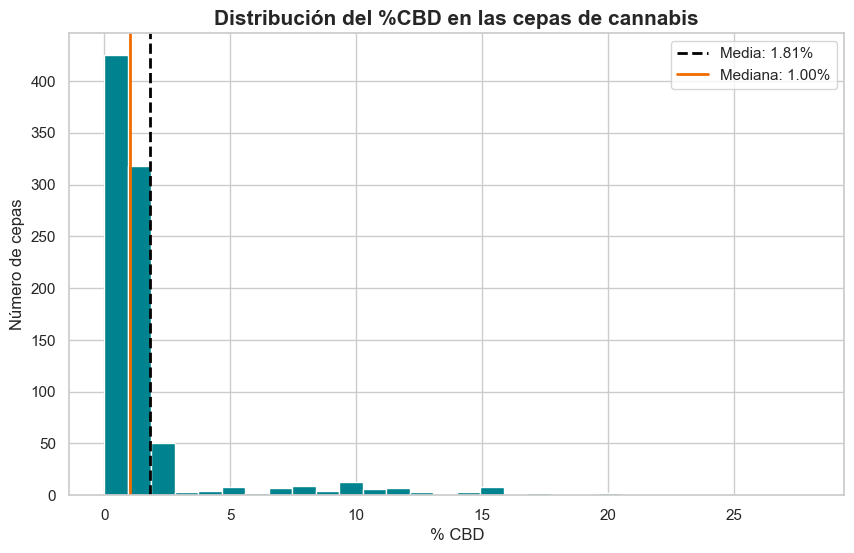

In [5]:
media_cbd = df["cbd_pct"].mean()
mediana_cbd = df["cbd_pct"].median()

fig, ax = plt.subplots()
ax.hist(df["cbd_pct"], bins=30, color=PALETTE["teal"], edgecolor="white")
ax.axvline(media_cbd, color="black", linestyle="--", linewidth=2, label=f"Media: {media_cbd:.2f}%")
ax.axvline(mediana_cbd, color=PALETTE["orange"], linestyle="-", linewidth=2, label=f"Mediana: {mediana_cbd:.2f}%")

ax.set_title("Distribución del %CBD en las cepas de cannabis")
ax.set_xlabel("% CBD")
ax.set_ylabel("Número de cepas")
ax.legend()
save_fig("02_distribucion_cbd")
plt.show()

**Interpretación.** Entre el 10% de cepas con CBD numérico, vemos un **sesgo positivo** claro: casi todas
tienen CBD muy bajo (1–2%), con una cola de pocas que llegan más alto. Fíjate en la pista estadística del
gráfico: la **media (1,81%) es mayor que la mediana (1,00%)**, justo la firma de una distribución con cola a
la derecha. Y coincide con lo que ya decían las etiquetas `"Low"` del 84% restante: **este catálogo está
pensado para el efecto psicoactivo (THC), no para uso terapéutico (CBD).** Dos fuentes distintas, misma
conclusión — eso da confianza.

> 💡 **Lección práctica:** cuando media > mediana, sospecha de una cola a la derecha. Ese detalle, que aquí
> confirmamos con el gráfico, es algo que un buen analista *nota solo con los números*.

## 3. ¿Cambia la potencia según el tipo de cepa?

Comparamos el THC de Indica, Sativa e Híbrido. Para comparar **grupos** la herramienta ideal es el
**boxplot** (diagrama de caja).

> 🧠 **Cómo leer un boxplot.** Cada caja resume un grupo:
> - La **línea dentro de la caja** = la mediana.
> - La **caja** va del primer cuartil (Q1, el 25% más bajo) al tercero (Q3, el 75%). Su alto se llama
>   **rango intercuartílico (IQR)** y mide la "dispersión" del grueso de los datos.
> - Los **bigotes** llegan hasta los valores aún "normales"; los **puntos sueltos** son *outliers*
>   (valores atípicos, inusualmente altos o bajos).
>
> Comparar cajas nos dice de un vistazo si un grupo es más potente (caja más arriba) o más variable
> (caja más alta) que otro.

Cepas con THC real y posible: 1415 de 8910 (16%)


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\03_thc_por_tipo.png


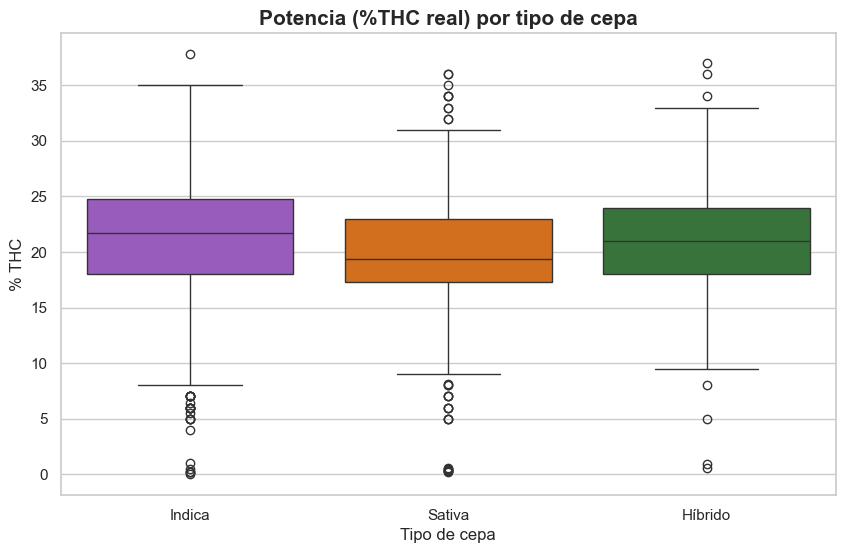

Mediana de THC real por tipo:
type_simple
Híbrido    21.0
Indica     21.7
Sativa     19.4
Name: thc_pct, dtype: float64


In [6]:
orden = ["Indica", "Sativa", "Híbrido"]

# Analizamos SOLO el THC real: quitamos el 20% por defecto y los valores imposibles (fuera de 0-100%).
# Si usáramos todos los datos, el 69% "pegado" en 20% aplastaría cualquier diferencia entre tipos.
df_real_thc = df[(df["thc_pct"] != 20.0) & (df["thc_pct"].between(0, 100))]
print(f"Cepas con THC real y posible: {len(df_real_thc)} de {len(df)} ({len(df_real_thc)/len(df)*100:.0f}%)")

fig, ax = plt.subplots()
sns.boxplot(
    data=df_real_thc, x="type_simple", y="thc_pct",
    order=orden, hue="type_simple", hue_order=orden,
    palette=TYPE_COLORS, legend=False, ax=ax,
)
ax.set_title("Potencia (%THC real) por tipo de cepa")
ax.set_xlabel("Tipo de cepa")
ax.set_ylabel("% THC")
save_fig("03_thc_por_tipo")
plt.show()

print("Mediana de THC real por tipo:")
print(df_real_thc.groupby("type_simple")["thc_pct"].median().round(1))

**Interpretación.** Al mirar solo el THC **real** (~16% de cepas con dato fiable), aparece una diferencia
que el valor por defecto escondía: la **Indica** es ligeramente más potente (mediana ~21,7%), la **Sativa**
algo menos (~19,4%) y el **Híbrido** queda en medio (~21%). Es un guiño a la creencia popular de que "las
Indicas pegan más"... pero **ojo**: la diferencia es **pequeña** (2 puntos de mediana) y las cajas se solapan
bastante. Conclusión honesta: *hay una tendencia leve, no una regla*. Y aún así se apoya solo en ~1 de cada 6
cepas, así que la tomamos con pinzas.

## 4. ¿THC y CBD van de la mano?

Última pregunta química: ¿las cepas con más THC tienen también más CBD, o es al revés? Para relacionar
**dos variables numéricas** usamos un **gráfico de dispersión** (scatter): cada punto es una cepa, ubicada
según su THC (eje X) y su CBD (eje Y).

> 🧠 **Correlación.** El coeficiente de correlación de Pearson (*r*) resume esa relación en un número entre
> −1 y +1:
> - **+1**: cuando una sube, la otra sube (relación positiva perfecta).
> - **−1**: cuando una sube, la otra baja (negativa perfecta).
> - **0**: no hay relación lineal.
>
> ⚠️ **Correlación no es causalidad.** Que dos cosas se muevan juntas no significa que una *cause* la otra.

Correlación de Pearson (THC vs CBD): r = -0.69  (calculada sobre 701 cepas con ambos números)


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\04_thc_vs_cbd.png


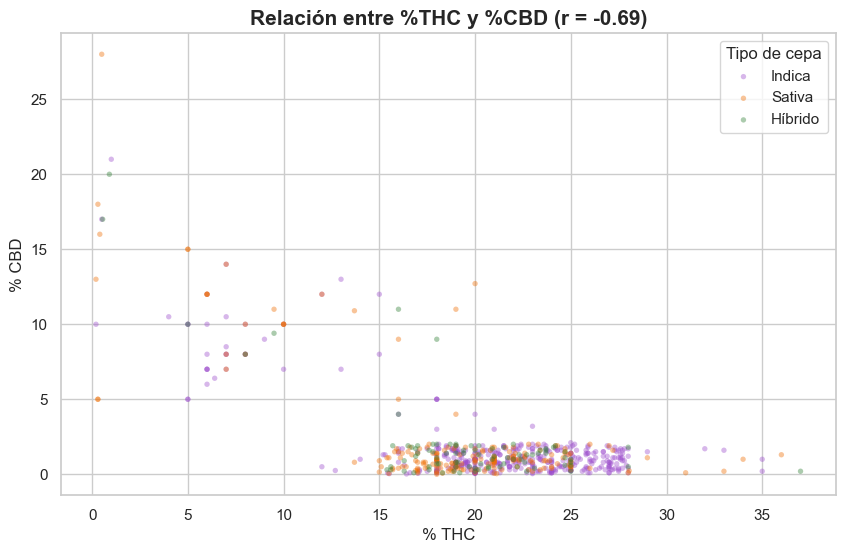

In [7]:
r = df["thc_pct"].corr(df["cbd_pct"])
n_pares = df[["thc_pct", "cbd_pct"]].dropna().shape[0]
print(f"Correlación de Pearson (THC vs CBD): r = {r:.2f}  (calculada sobre {n_pares} cepas con ambos números)")

fig, ax = plt.subplots()
# Un color por tipo, para ver si algún grupo se comporta distinto
for tipo in orden:
    subset = df[df["type_simple"] == tipo]
    ax.scatter(
        subset["thc_pct"], subset["cbd_pct"],
        color=TYPE_COLORS[tipo], label=tipo,
        alpha=0.4, s=15, edgecolors="none",
    )
ax.set_title(f"Relación entre %THC y %CBD (r = {r:.2f})")
ax.set_xlabel("% THC")
ax.set_ylabel("% CBD")
ax.legend(title="Tipo de cepa")
save_fig("04_thc_vs_cbd")
plt.show()

**Interpretación.** La correlación es **moderada y negativa** (r = −0,69): cuando una sube, la otra tiende
a bajar. El scatter muestra por qué se forman **dos grupos**: uno arriba a la derecha —THC alto y CBD casi
cero— y otro a la izquierda —THC bajo y CBD más alto (5–28%)—. Es decir, las cepas suelen ser "de THC" **o**
"de CBD", rara vez las dos cosas. Encaja con la biología: ambos compuestos compiten por el mismo precursor
químico en la planta, así que favorecer uno tiende a reducir el otro. La relación **se mantiene** aunque
quitemos el valor por defecto (r sigue ≈ −0,70), así que es **real**, no un artefacto. Eso sí: se calcula
sobre solo **701 cepas** (las que tienen THC y CBD numéricos a la vez), así que es una muestra modesta.

> ⚠️ **Correlación no es causalidad.** Que THC y CBD se muevan en direcciones opuestas no significa que uno
> "cause" la bajada del otro: comparten una causa común (la bioquímica de la planta). Confundir correlación
> con causalidad es uno de los errores más típicos —y peligrosos— al analizar datos.

---
### 📝 Resumen de la Parte 1 (Perfil químico)

- ⚠️ **El THC es poco confiable:** el 69% vale 20% exacto (valor por defecto del scraper) y hay valores
  imposibles (negativos). *Detectar esto es el hallazgo más importante de la sección.*
- El **CBD sí es confiable:** bajo en casi todas, con **sesgo positivo** (cola a la derecha). Catálogo
  claramente orientado al THC, no al uso terapéutico.
- Con el **THC real** (31% de cepas), la Indica es levemente más potente que la Sativa: una **tendencia
  leve**, no una regla.
- THC y CBD tienen una correlación **moderada y negativa** (r ≈ −0,69), real y explicable por la biología.
  Pero **correlación no es causalidad**.

**Siguiente (Parte 2):** efectos y usos medicinales — e investigamos el sospechoso efecto `Relaxing` que
detectamos en la limpieza (mismo patrón de valor por defecto que acabamos de ver con el THC).